In [72]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.manifold import TSNE  # for dimension reduction
import matplotlib.pyplot as plt
from pathlib import Path

In [40]:
embeddings = torch.load('fm-rna_embeddings.pt')

In [41]:
embeddings = [torch.mean(emb, dim=0).numpy() for emb in embeddings.values()]
embeddings = np.array(embeddings)

In [42]:
embeddings.shape

(2654, 640)

In [ ]:
# tsne = TSNE(n_components=2, random_state=42)
# reduced_embeddings = tsne.fit_transform(embeddings)
# print(reduced_embeddings.shape)

(2654, 2)


In [73]:
scaled_data = StandardScaler().fit_transform(embeddings)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
reduced_embeddings = reducer.fit_transform(scaled_data)

c:\Users\Julius\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


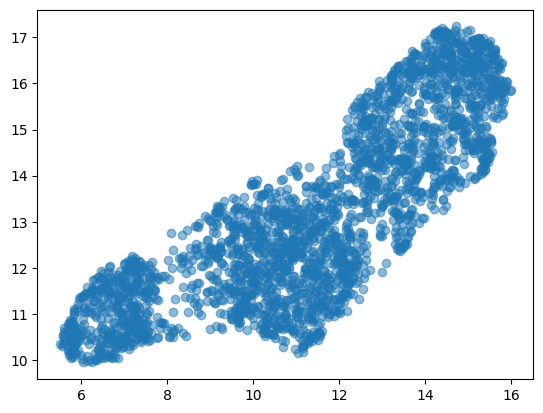

In [78]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.5)

In [79]:
import os

In [80]:
os.getcwd()

'c:\\Julius_SSD\\Stanford\\Stanford_3_JuniorYear\\Stanford_3_3_Spring\\CS229\\cs229_rna_folding\\modular_setup'

In [81]:
arr_seqlength = np.loadtxt('../kinpfn_testing_set/parquet_parsing/arr_seqlength.txt')
arr_medlogfpt = np.loadtxt('../kinpfn_testing_set/parquet_parsing/arr_medlogfpt.txt')

In [82]:
arr_medlogfpt.shape

(2654,)

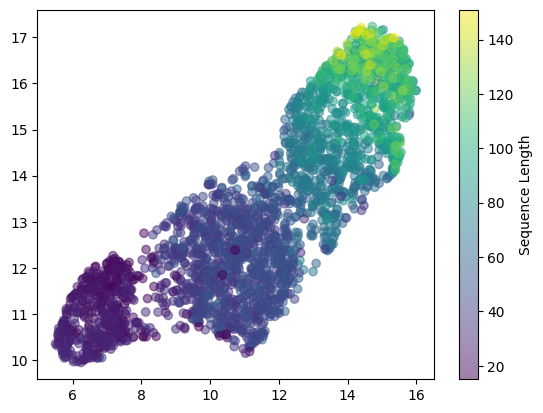

In [84]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.5,
            c=arr_seqlength, cmap='viridis')

plt.colorbar(label='Sequence Length')

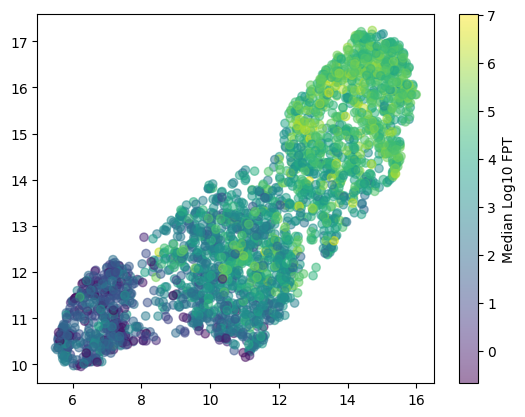

In [85]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.5,
            c=arr_medlogfpt, cmap='viridis')

plt.colorbar(label='Median Log10 FPT')